<a href="https://colab.research.google.com/github/emcgeever-husky/Econ3916/blob/main/Assignment%203/Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
## imports
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn

## Phase 1: Bootstrapping Non-Parametric Uncertainty

### The Zero-Inflated Gig Economy Tip Distribution

In [76]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])
median = np.median(driver_tips)
print(median)

0.7553316913699188


### The Manual Bootstrap Engine

In [77]:
n_boot = 10000
n = len(driver_tips)

boot_medians = []
for _ in range(n_boot):
    resample = np.random.choice(driver_tips, size=n, replace=True)
    boot_medians.append(np.median(resample))

ci_lo, ci_hi = np.percentile(boot_medians, [2.5, 97.5])
print(ci_lo, ci_hi)

0.2653018357387816 1.3635639228066991


In [78]:
### calculating:
lower_bound_margin = median - ci_lo
upper_bound_margin = ci_hi - median
print(lower_bound_margin, upper_bound_margin)

0.49002985563113727 0.6082322314367803


#### Analysis: Taking the difference in median we can see the expected outcome that the median is closer to the lower bound then the true center, skewed this way from the large quantity of $0 tips. The upward push is from those rarer extra generous tippers who stretch the upper end with a larger tail.

## Phase 2: Falsification in Logistics A/B Testing

### The Algorithmic Routing Crash

In [79]:
np.random.seed(2)

control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_difference = control.mean() - treatment.mean()

print(observed_difference)

3.5492133907791974


### The Exact Non-Parametric Permutation

In [80]:
all_deliveries = np.concatenate([control, treatment])

perm_differences = []
for num in range(5000):
    shuffled = np.random.permutation(all_deliveries)
    perm_differences.append(shuffled[:500].mean() - shuffled[500:].mean())

perm_diffs = np.array(perm_differences)
p_value = np.mean(np.abs(perm_differences) >= np.abs(observed_difference))
print(p_value)

0.0


0 out of 5000 random permutations yielded differences equal to or more extreme than your observed empirical difference, meaning it is very unlikely (< 1/5000) that the impact of the new batch routing algorithm on delivery times is due to chance.

## Phase 3: Causal Control and the Mitigation of Selection Bias

### The Loyalty Program Paradox

In [81]:
df = pd.read_csv('swiftcart_loyalty.csv')

subs = df[df['subscriber'] == 1]['post_spend']
non_subs = df[df['subscriber'] == 0]['post_spend']

SDO = subs.mean() - non_subs.mean()
print(SDO)

17.57066938452379


### Propensity Score Matching (PSM) Architecture

In [82]:
# propensity score (using pre-treatment co-var)
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

model = sklearn.linear_model.LogisticRegression()
model.fit(X, D)
df['propensity_score'] = model.predict_proba(X)[:, 1]

# use near. neigh. to match subs and non subs together based on closest scores
# make new dataframes based on if sub or nonsub
treated = df[df['subscriber'] == 1]
control = df[df['subscriber'] == 0]

nn = sklearn.neighbors.NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()]

# Average Treatment Effect
ATT = treated['post_spend'].values.mean() - matched_control['post_spend'].values.mean()
print("SDO is:", SDO)
print("ATT is:", ATT)

SDO is: 17.57066938452379
ATT is: 9.913855182824861


## Phase 4: AI Expansion

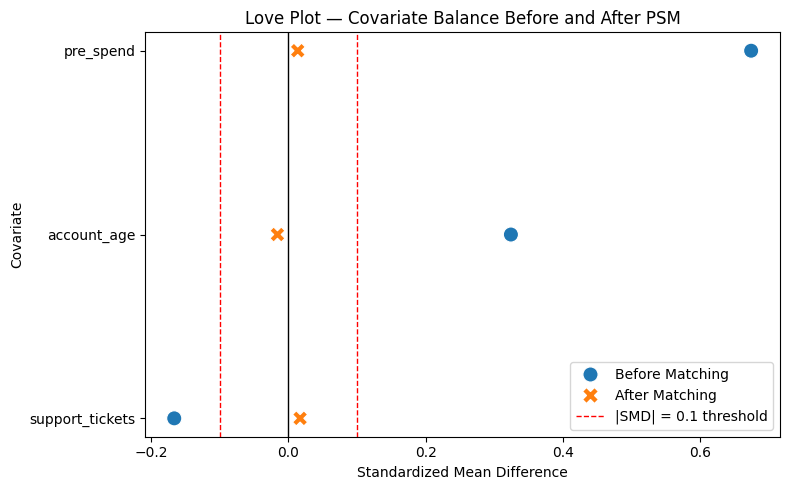

In [83]:
df_unmatched = df.copy()
df_matched = pd.concat([
    treated.reset_index(drop=True),
    matched_control.reset_index(drop=True)
])

def standardized_mean_diff(df, covariates):
    treated = df[df['subscriber'] == 1]
    control = df[df['subscriber'] == 0]
    smd = {}
    for col in covariates:
        diff = treated[col].mean() - control[col].mean()
        pooled_std = np.sqrt((treated[col].std()**2 + control[col].std()**2) / 2)
        smd[col] = diff / pooled_std
    return smd

covariates = ['pre_spend', 'account_age', 'support_tickets']
smd_before = standardized_mean_diff(df_unmatched, covariates)
smd_after  = standardized_mean_diff(df_matched, covariates)

plot_df = pd.DataFrame({
    'covariate': covariates * 2,
    'SMD':       list(smd_before.values()) + list(smd_after.values()),
    'stage':     ['Before Matching'] * 3 + ['After Matching'] * 3
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='SMD', y='covariate', hue='stage',
                style='stage', s=120, ax=ax)
ax.axvline(0,    color='black', lw=1.0, ls='-')
ax.axvline(0.1,  color='red',   lw=1.0, ls='--', label='|SMD| = 0.1 threshold')
ax.axvline(-0.1, color='red',   lw=1.0, ls='--')
ax.set_xlabel('Standardized Mean Difference')
ax.set_ylabel('Covariate')
ax.set_title('Love Plot — Covariate Balance Before and After PSM')
ax.legend()
plt.tight_layout()
plt.show()

All three pre-treatment covariates (pre_spend, account_age, support_tickets) crossed inside the ±0.1 SMD threshold after matching, confirming that PSM successfully eliminated the selection bias present in the raw data. The ATT estimate is therefore a defensible causal estimate of the effect of SwiftPass subscription on post-treatment spending, not an artifact of pre-existing differences between subscribers and non-subscribers.